In [ ]:
## Devin SaJeun DuCharme
## CS790 Homework 3
## PyTorch Compile Analysis

In [1]:
# Imports
import time
import torch
import torch.nn as nn
import torch._dynamo as dynamo
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.fx.experimental.proxy_tensor import make_fx

Device: cuda

Testing backend: eager
Average time per iteration: 0.001170 seconds

Testing backend: aot_eager
Average time per iteration: 0.002108 seconds

Testing backend: cudagraphs
Average time per iteration: 0.003571 seconds


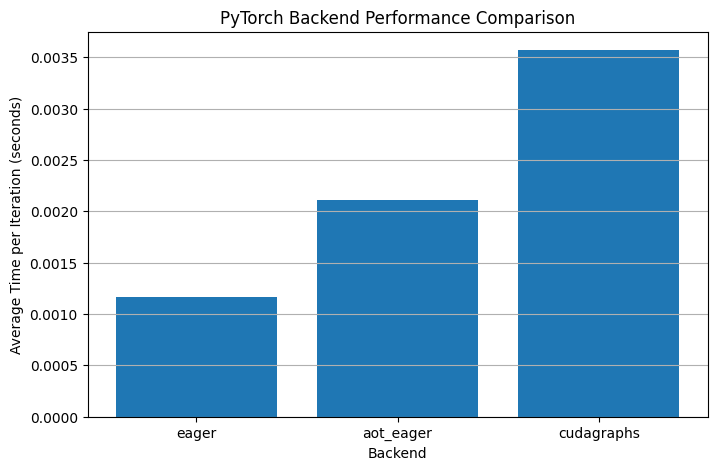

In [2]:
## Part 1: Comparing Backends

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Simple neural network with 3 linear layers and ReLU activations
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Linear(2048, 10)
        )

    def forward(self, x):
        return self.net(x)

# Input and target tensors
batch_size = 512
x = torch.randn(batch_size, 1024, device=device)
target = torch.randn(batch_size, 10, device=device)

# Loss function
criterion = nn.MSELoss()

# Backends to compare
backends = ["eager", "aot_eager", "cudagraphs"]

# Storage for results
backend_names = []
average_times = []

# GPU synchronization helper
def synchronize_if_needed():
    if device == "cuda":
        torch.cuda.synchronize()

# Compare backends
for backend in backends:
    print(f"\nTesting backend: {backend}")
    
    try:
        # Fresh model and optimizer for each backend
        model = SimpleNet().to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

        # Compile model
        compiled_model = torch.compile(model, backend=backend)

        # Warmup iteration
        optimizer.zero_grad()
        output = compiled_model(x)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        synchronize_if_needed()

        # Timed iterations
        start_time = time.perf_counter()

        for _ in range(100):
            optimizer.zero_grad()
            output = compiled_model(x)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        synchronize_if_needed()
        end_time = time.perf_counter()

        avg_time = (end_time - start_time) / 100.0

        backend_names.append(backend)
        average_times.append(avg_time)

        print(f"Average time per iteration: {avg_time:.6f} seconds")

    except Exception as e:
        print(f"Backend {backend} failed: {e}")

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(backend_names, average_times)

plt.xlabel("Backend")
plt.ylabel("Average Time per Iteration (seconds)")
plt.title("PyTorch Backend Performance Comparison")
plt.grid(axis="y")

plt.show()

In [4]:
## Part 2: Debugging Compilation Failures

# Example input
x = torch.randn(128, 128, device=device)

# Problem 1: Broken version
def problem1(x):
    # This should fail to compile
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

print("\nProblem 1 (broken)")
try:
    compiled_problem1 = torch.compile(problem1, backend="eager", fullgraph=True)
    compiled_problem1(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp1 = torch._dynamo.explain(problem1)(x)
    print("Graph count:", exp1.graph_count)
    print("Graph break count:", exp1.graph_break_count)
    print("Break reasons:", exp1.break_reasons)
except Exception as e:
    print("Explain failed:", e)

# Problem 1: Fixed version
def problem1_fixed(x):
    return torch.where(x.sum() > 0, x * 2, x / 2)

print("\nProblem 1 (fixed)")
try:
    compiled_problem1_fixed = torch.compile(problem1_fixed, backend="eager", fullgraph=True)
    compiled_problem1_fixed(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp1_fixed = torch._dynamo.explain(problem1_fixed)(x)
    print("Graph count:", exp1_fixed.graph_count)
    print("Graph break count:", exp1_fixed.graph_break_count)
    print("Break reasons:", exp1_fixed.break_reasons)
except Exception as e:
    print("Explain failed:", e)



# Problem 2: Broken version
def problem2(x):
    # This should also have issues
    d = {}
    d["key"] = x
    return d["key"] * 2

print("\nProblem 2 (broken)")
try:
    compiled_problem2 = torch.compile(problem2, backend="eager", fullgraph=True)
    compiled_problem2(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp2 = torch._dynamo.explain(problem2)(x)
    print("Graph count:", exp2.graph_count)
    print("Graph break count:", exp2.graph_break_count)
    print("Break reasons:", exp2.break_reasons)
except Exception as e:
    print("Explain failed:", e)

# Problem 2: Fixed version
def problem2_fixed(x):
    return x * 2

print("\nProblem 2 (fixed)")
try:
    compiled_problem2_fixed = torch.compile(problem2_fixed, backend="eager", fullgraph=True)
    compiled_problem2_fixed(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp2_fixed = torch._dynamo.explain(problem2_fixed)(x)
    print("Graph count:", exp2_fixed.graph_count)
    print("Graph break count:", exp2_fixed.graph_break_count)
    print("Break reasons:", exp2_fixed.break_reasons)
except Exception as e:
    print("Explain failed:", e)



# Problem 3: Broken version
def problem3(x):
    # This might have suboptimal performance
    result = 0
    for i in range(10):
        result += (x + i).sum()
    return result

print("\nProblem 3 (broken)")
try:
    compiled_problem3 = torch.compile(problem3, backend="eager", fullgraph=True)
    compiled_problem3(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp3 = torch._dynamo.explain(problem3)(x)
    print("Graph count:", exp3.graph_count)
    print("Graph break count:", exp3.graph_break_count)
    print("Break reasons:", exp3.break_reasons)
except Exception as e:
    print("Explain failed:", e)

# Problem 3: Fixed version
def problem3_fixed(x):
    offsets = torch.arange(10, device=x.device, dtype=x.dtype).view(10, 1, 1)
    return (x.unsqueeze(0) + offsets).sum()

print("\nProblem 3 (fixed)")
try:
    compiled_problem3_fixed = torch.compile(problem3_fixed, backend="eager", fullgraph=True)
    compiled_problem3_fixed(x)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

try:
    exp3_fixed = torch._dynamo.explain(problem3_fixed)(x)
    print("Graph count:", exp3_fixed.graph_count)
    print("Graph break count:", exp3_fixed.graph_break_count)
    print("Break reasons:", exp3_fixed.break_reasons)
except Exception as e:
    print("Explain failed:", e)




Problem 1 (broken)
Compilation failed: Dynamic control flow is not supported at the moment. Please use functorch.experimental.control_flow.cond to explicitly capture the control flow. For more information about this error, see: https://pytorch.org/docs/main/generated/exportdb/index.html#cond-operands

from user code:
   File "C:\Users\ducha\AppData\Local\Temp\ipykernel_28452\3253069158.py", line 9, in problem1
    if x.sum() > 0:

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True

Graph count: 2
Graph break count: 1
Break reasons: [GraphCompileReason(reason='generic_jump TensorVariable()', user_stack=[<FrameSummary file C:\Users\ducha\AppData\Local\Temp\ipykernel_28452\3253069158.py, line 9 in problem1>], graph_break=True)]

Problem 1 (fixed)
Compilation succeeded
Graph count: 1
Graph break count: 0
Break reasons: []

Probl

In [3]:
## Part 3: Graph Capture and Inspection

# Example input
x = torch.randn(4, 4, device=device)
w1 = torch.randn(4, 4, device=device)
w2 = torch.randn(4, 4, device=device)

# Function with required operations
def graph_example(x, w1, w2):
    y = x @ w1                
    y = F.relu(y)              
    y = y @ w2                
    y = y + x                 
    y = F.layer_norm(y, y.shape[1:])   

    print("Hello")             
    my_list = []
    my_list.append(1)          

    return y

# Try compiling
print("\nCompiled run")
try:
    compiled_fn = torch.compile(graph_example, backend="eager", fullgraph=True)
    compiled_fn(x, w1, w2)
    print("Compilation succeeded")
except Exception as e:
    print("Compilation failed:", e)

# Explain graph capture
print("\nDynamo explain output")
try:
    exp = torch._dynamo.explain(graph_example)(x, w1, w2)
    print("Graph count:", exp.graph_count)
    print("Graph break count:", exp.graph_break_count)
    print("Break reasons:", exp.break_reasons)
except Exception as e:
    print("Explain failed:", e)

# Inspect intermediate graph with make_fx
print("\nmake_fx graph")
try:
    traced = make_fx(graph_example)(x, w1, w2)
    print(traced.graph)
except Exception as e:
    print("make_fx failed:", e)


Compiled run
Compilation failed: builtin: print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

from user code:
   File "C:\Users\ducha\AppData\Local\Temp\ipykernel_28452\943455841.py", line 16, in graph_example
    print("Hello")

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True


Dynamo explain output
Hello
Graph count: 1
Graph break count: 0
Break reasons: [GraphCompileReason(reason="builtin: print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False", user_stack=[<FrameSummary file C:\Users\ducha\AppData\Local\Temp\ipykernel_28452\943455841.py, line 16 in graph_example>], graph_break=True)]

make_fx graph
Hello
graph():
    %x_1 : [num_users=2] = placeholder[target=x_1]
    %w1_1 : [num_users=1] = placeholder[target=w1_1]
    %w2_1 : [num_users=1] = placeholder[target=w2_1]
    %mm :